## Session setup

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_URL = "https://github.com/Mudibo/AgriSence.git"

if IN_COLAB:
    REPO_DIR = Path("/content/AgriSence")
    if not REPO_DIR.exists():
        !git clone {REPO_URL} {REPO_DIR}
    %cd {REPO_DIR / "model"}
else:
    current_dir = Path.cwd().resolve()
    if current_dir.name == "model":
        repo_model_dir = current_dir
    elif (current_dir / "model").exists():
        repo_model_dir = current_dir / "model"
    elif current_dir.parent.name == "AgriSence" and (current_dir.parent / "model").exists():
        repo_model_dir = current_dir.parent / "model"
    else:
        raise FileNotFoundError(
            "Could not find the AgriSence/model directory. Start this notebook from the repo root or the model folder."
        )
    %cd {repo_model_dir}
# Local imports for project modules
from config.constants import CROPS, MARKETS

if Path("requirements.txt").exists():
    !pip install -r requirements.txt
else:
    raise FileNotFoundError("requirements.txt was not found in the current working directory.")


/content/AgriSence/model


# 1. Load raw dataset

In [2]:
WFP_URL = (
    "https://data.humdata.org/dataset/wfp-food-prices-for-kenya/resource/"
    "517ee1bf-2437-4f8c-aa1b-cb9925b9d437/download/wfp_food_prices_ken.csv"
)

raw_df = pd.read_csv(WFP_URL)

# HDX exports ship a units/type row directly under the header
if raw_df.iloc[0].astype(str).str.match(r"^#").any():
    raw_df = raw_df.iloc[1:].reset_index(drop=True)

print(raw_df.shape)


(27774, 16)


# 2. Structural inspection

In [3]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27774 entries, 0 to 27773
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          27774 non-null  object 
 1   admin1        27706 non-null  object 
 2   admin2        27706 non-null  object 
 3   market        27774 non-null  object 
 4   market_id     27774 non-null  int64  
 5   latitude      27706 non-null  float64
 6   longitude     27706 non-null  float64
 7   category      27774 non-null  object 
 8   commodity     27774 non-null  object 
 9   commodity_id  27774 non-null  int64  
 10  unit          27774 non-null  object 
 11  priceflag     27774 non-null  object 
 12  pricetype     27774 non-null  object 
 13  currency      27774 non-null  object 
 14  price         27774 non-null  float64
 15  usdprice      27774 non-null  float64
dtypes: float64(4), int64(2), object(10)
memory usage: 3.4+ MB


In [4]:
for col in raw_df.columns:
    print(f"--- {col} ---")
    print(raw_df[col].dropna().unique()[:15])
    print()

--- date ---
['2006-01-15' '2006-02-15' '2006-03-15' '2006-04-15' '2006-05-15'
 '2006-06-15' '2006-07-15' '2006-08-15' '2006-09-15' '2006-10-15'
 '2006-11-15' '2006-12-15' '2007-01-15' '2007-02-15' '2007-03-15']

--- admin1 ---
['Coast' 'Eastern' 'Nairobi' 'North Eastern' 'Nyanza' 'Rift Valley'
 'Central']

--- admin2 ---
['Mombasa' 'Kitui' 'Marsabit' 'Nairobi' 'Mandera' 'Kisumu' 'Turkana'
 'Uasin Gishu' 'Nakuru' 'Kilifi' 'Garissa' 'Baringo' 'Kajiado' 'Nyeri'
 'Kwale']

--- market ---
['Mombasa' 'Kitui' 'Marsabit' 'Nairobi' 'Mandera' 'Kisumu'
 'Lodwar (Turkana)' 'Eldoret town (Uasin Gishu)' 'Nakuru'
 'Hola (Tana River)' 'Kilifi' 'Garissa' 'Marigat (Baringo)' 'Kajiado'
 'Karatina (Nyeri)']

--- market_id ---
[ 191  187  190  184  189  186  188  185 1850 1854 1852 1855 1851 1853
 5670]

--- latitude ---
[-4.05 -1.37  2.33 -1.28  3.94 -0.1   3.12  0.52 -0.28 -3.63 -0.46  0.46
 -1.84 -0.48 -4.66]

--- longitude ---
[39.67 38.02 37.98 36.82 41.86 34.75 35.6  35.28 36.07 39.85 39.65 35.96
 3

In [5]:
# Check unit consistency per commodity — critical before any cross-market comparison
raw_df.groupby('commodity')['unit'].unique()

,unit
commodity,
Bananas,[Unit]
Beans,[KG]
Beans (dolichos),[90 KG]
Beans (dry),"[90 KG, KG]"
Beans (kidney),[90 KG]
Beans (mung),[90 KG]
Beans (rosecoco),[90 KG]
Beans (yellow),[90 KG]
Bread,[400 G]


# 3. Standardize market and commodity naming

In [6]:
# TODO: confirm exact market/commodity string values from Step 2, then standardize
raw_df['market'] = raw_df['market'].str.strip().str.title()
raw_df['commodity'] = raw_df['commodity'].str.strip().str.title()

# 4. Filter to target markets

In [7]:
market_df = raw_df[raw_df['market'].isin(MARKETS)].copy()
print(f"Rows before market filter: {len(raw_df)}")
print(f"Rows after market filter: {len(market_df)}")
market_df['market'].value_counts()

Rows before market filter: 27774
Rows after market filter: 3881


,count
market,
Nairobi,1762
Kisumu,962
Mombasa,616
Nakuru,541


# 5. Crop coverage analysis — data-driven crop selection

In [8]:
# Record count per commodity across the 5 target markets
crop_coverage = (
    market_df.groupby('commodity')
    .agg(total_records=('commodity', 'count'),
         markets_covered=('market', 'nunique'),
         date_min=('date', 'min'),
         date_max=('date', 'max'))
    .sort_values('total_records', ascending=False)
)
crop_coverage.head(20)

,total_records,markets_covered,date_min,date_max
commodity,,,,
Maize,648,4,2006-01-15,2022-04-15
Beans,576,4,2006-01-15,2021-11-15
Maize (White),563,4,2006-01-15,2020-03-15
Beans (Dry),555,4,2006-01-15,2020-08-15
Potatoes (Irish),397,4,2006-01-15,2020-08-15
Sorghum,396,4,2006-01-15,2020-08-15
Bread,178,1,2006-01-15,2020-12-15
"Milk (Cow, Pasteurized)",178,1,2006-01-15,2020-12-15
Oil (Vegetable),178,1,2006-01-15,2020-12-15


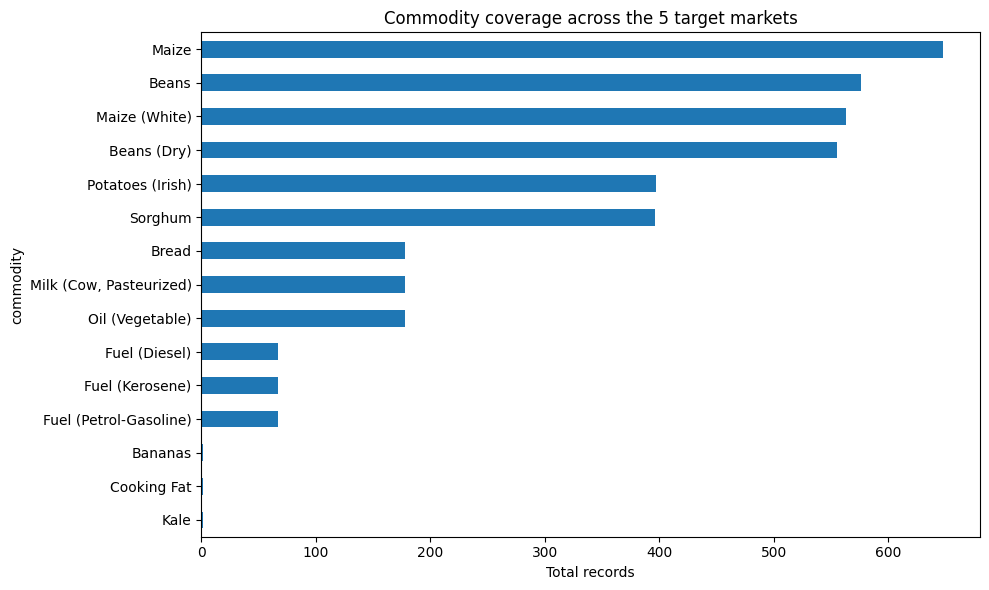

In [9]:
plt.figure(figsize=(10, 6))
crop_coverage.head(15)['total_records'].plot(kind='barh')
plt.xlabel('Total records')
plt.title('Commodity coverage across the 5 target markets')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

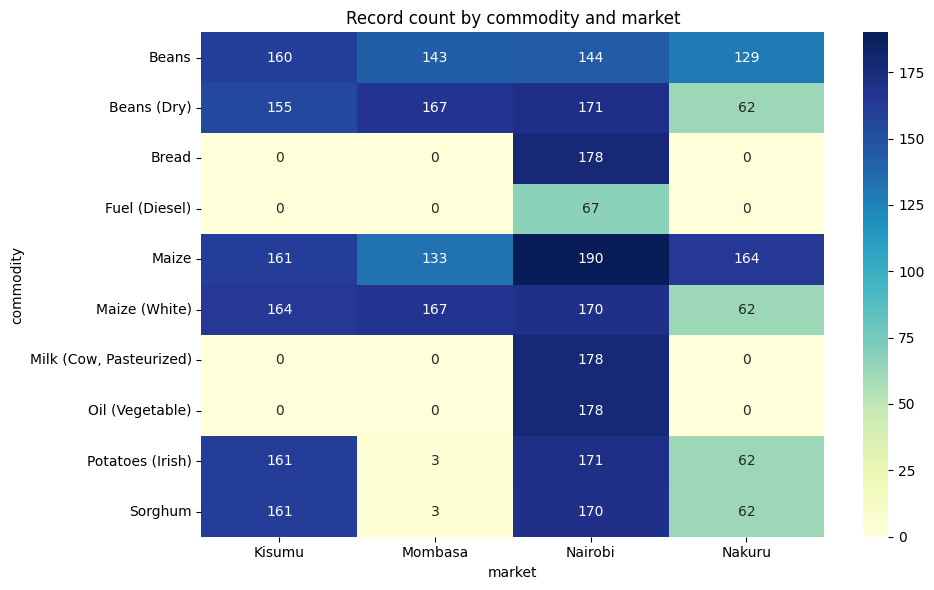

In [10]:
# Coverage breakdown per market for candidate crops — confirms no single market is a
# blind spot for the crops eventually selected
candidate_crops = crop_coverage.head(10).index.tolist()
coverage_matrix = (
    market_df[market_df['commodity'].isin(candidate_crops)]
    .groupby(['commodity', 'market'])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(10, 6))
sns.heatmap(coverage_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Record count by commodity and market')
plt.tight_layout()
plt.show()

In [11]:
# TODO: based on the above, confirm final crop selection.
# If the top 3 by coverage differ from the proposal's tomatoes/kale/onions,
# flag this explicitly for the supervisor before proceeding.
FINAL_CROPS = ['Maize','Beans','Beans (Dry)','Maize (White)']  # populate based on coverage_matrix results

# 6. Filter to final crop selection

In [12]:
df = market_df[market_df['commodity'].isin(FINAL_CROPS)].copy()
df['date'] = pd.to_datetime(df['date'])
print(df.shape)
df.groupby(['market', 'commodity']).size()

(2342, 16)


market   commodity    
Kisumu   Beans            160
         Beans (Dry)      155
         Maize            161
         Maize (White)    164
Mombasa  Beans            143
         Beans (Dry)      167
         Maize            133
         Maize (White)    167
Nairobi  Beans            144
         Beans (Dry)      171
         Maize            190
         Maize (White)    170
Nakuru   Beans            129
         Beans (Dry)       62
         Maize            164
         Maize (White)     62
dtype: int64

# 7. Duplicate detection

In [13]:
duplicates = df[df.duplicated(subset=['market', 'commodity', 'date'], keep=False)]
print(f"Duplicate (market, commodity, date) rows: {len(duplicates)}")
duplicates.sort_values(['market', 'commodity', 'date']).head(20)

Duplicate (market, commodity, date) rows: 2


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
6408,2020-08-15,Nairobi,Nairobi,Nairobi,184,-1.28,36.82,cereals and tubers,Maize,51,KG,actual,Retail,KES,52.00,0.48
6409,2020-08-15,Nairobi,Nairobi,Nairobi,184,-1.28,36.82,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,32.91,0.30


# 8. Missingness analysis

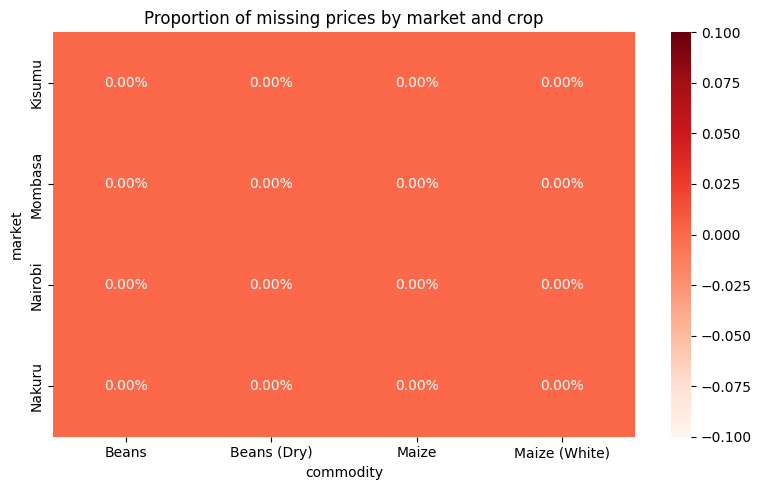

In [14]:
missing_by_market_crop = (
    df.groupby(['market', 'commodity'])['price']
    .apply(lambda x: x.isna().mean())
    .unstack()
)

plt.figure(figsize=(8, 5))
sns.heatmap(missing_by_market_crop, annot=True, fmt='.2%', cmap='Reds')
plt.title('Proportion of missing prices by market and crop')
plt.tight_layout()
plt.show()

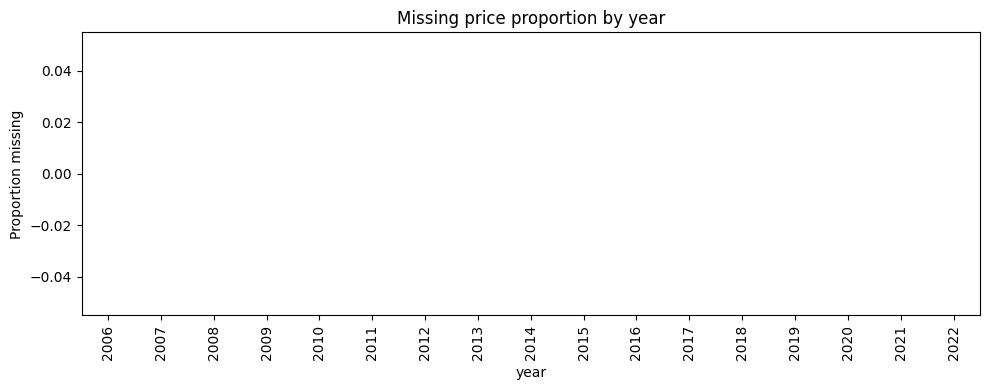

In [15]:
# Missingness over time — are gaps concentrated in earlier years?
df['year'] = df['date'].dt.year
missing_by_year = df.groupby('year')['price'].apply(lambda x: x.isna().mean())

plt.figure(figsize=(10, 4))
missing_by_year.plot(kind='bar')
plt.ylabel('Proportion missing')
plt.title('Missing price proportion by year')
plt.tight_layout()
plt.show()

# 9. Reporting frequency check

In [16]:
freq_check = (
    df.groupby(['market', 'commodity'])['date']
    .apply(lambda x: x.sort_values().diff().mode()[0] if len(x) > 1 else pd.NaT)
)
freq_check

market   commodity    
Kisumu   Beans           31 days
         Beans (Dry)     31 days
         Maize           31 days
         Maize (White)   31 days
Mombasa  Beans           31 days
         Beans (Dry)     31 days
         Maize           31 days
         Maize (White)   31 days
Nairobi  Beans           31 days
         Beans (Dry)     31 days
         Maize           31 days
         Maize (White)   31 days
Nakuru   Beans           31 days
         Beans (Dry)     31 days
         Maize           31 days
         Maize (White)   31 days
Name: date, dtype: timedelta64[ns]

# 10. Outlier and anomaly screening

In [17]:
print("Zero or negative prices:")
print(df[df['price'] <= 0])

Zero or negative prices:
Empty DataFrame
Columns: [date, admin1, admin2, market, market_id, latitude, longitude, category, commodity, commodity_id, unit, priceflag, pricetype, currency, price, usdprice, year]
Index: []


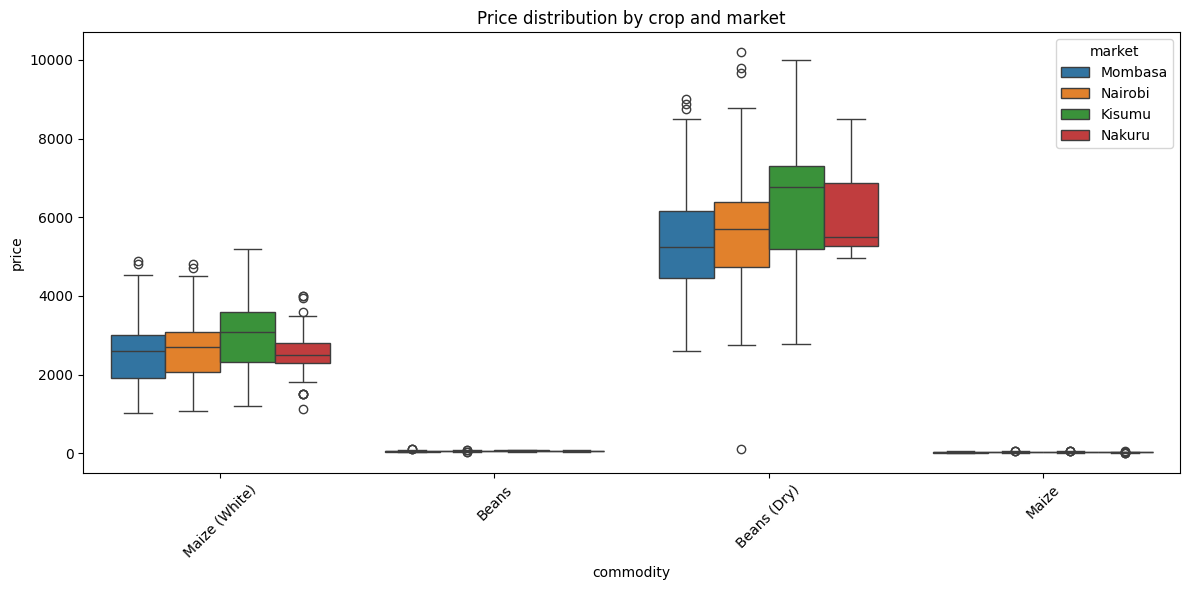

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='commodity', y='price', hue='market')
plt.title('Price distribution by crop and market')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 11. Time series visualization per market-crop combination

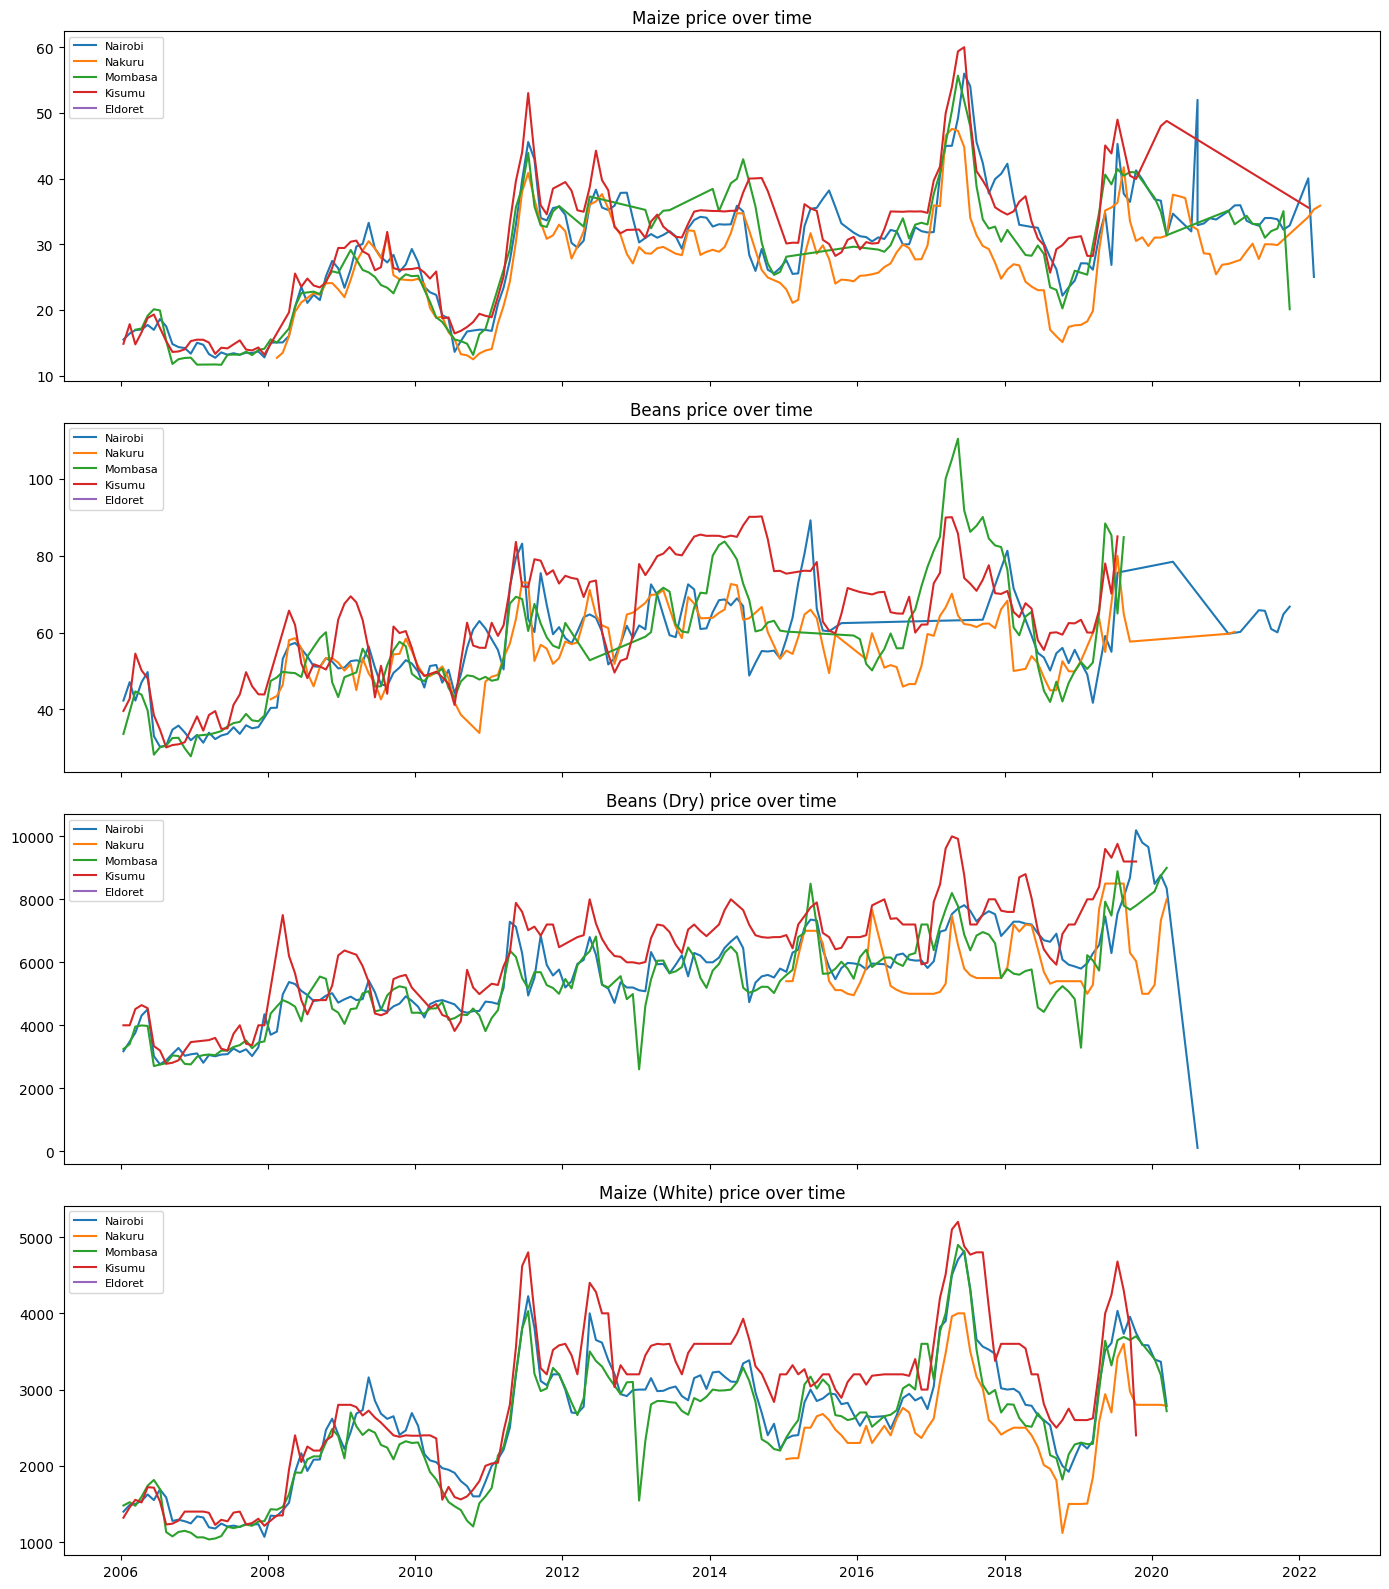

In [19]:
fig, axes = plt.subplots(len(FINAL_CROPS), 1, figsize=(14, 4 * len(FINAL_CROPS)), sharex=True)

for ax, crop in zip(axes, FINAL_CROPS):
    subset = df[df['commodity'] == crop]
    for market in MARKETS:
        market_subset = subset[subset['market'] == market].sort_values('date')
        ax.plot(market_subset['date'], market_subset['price'], label=market)
    ax.set_title(f'{crop} price over time')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# 12. Seasonality check

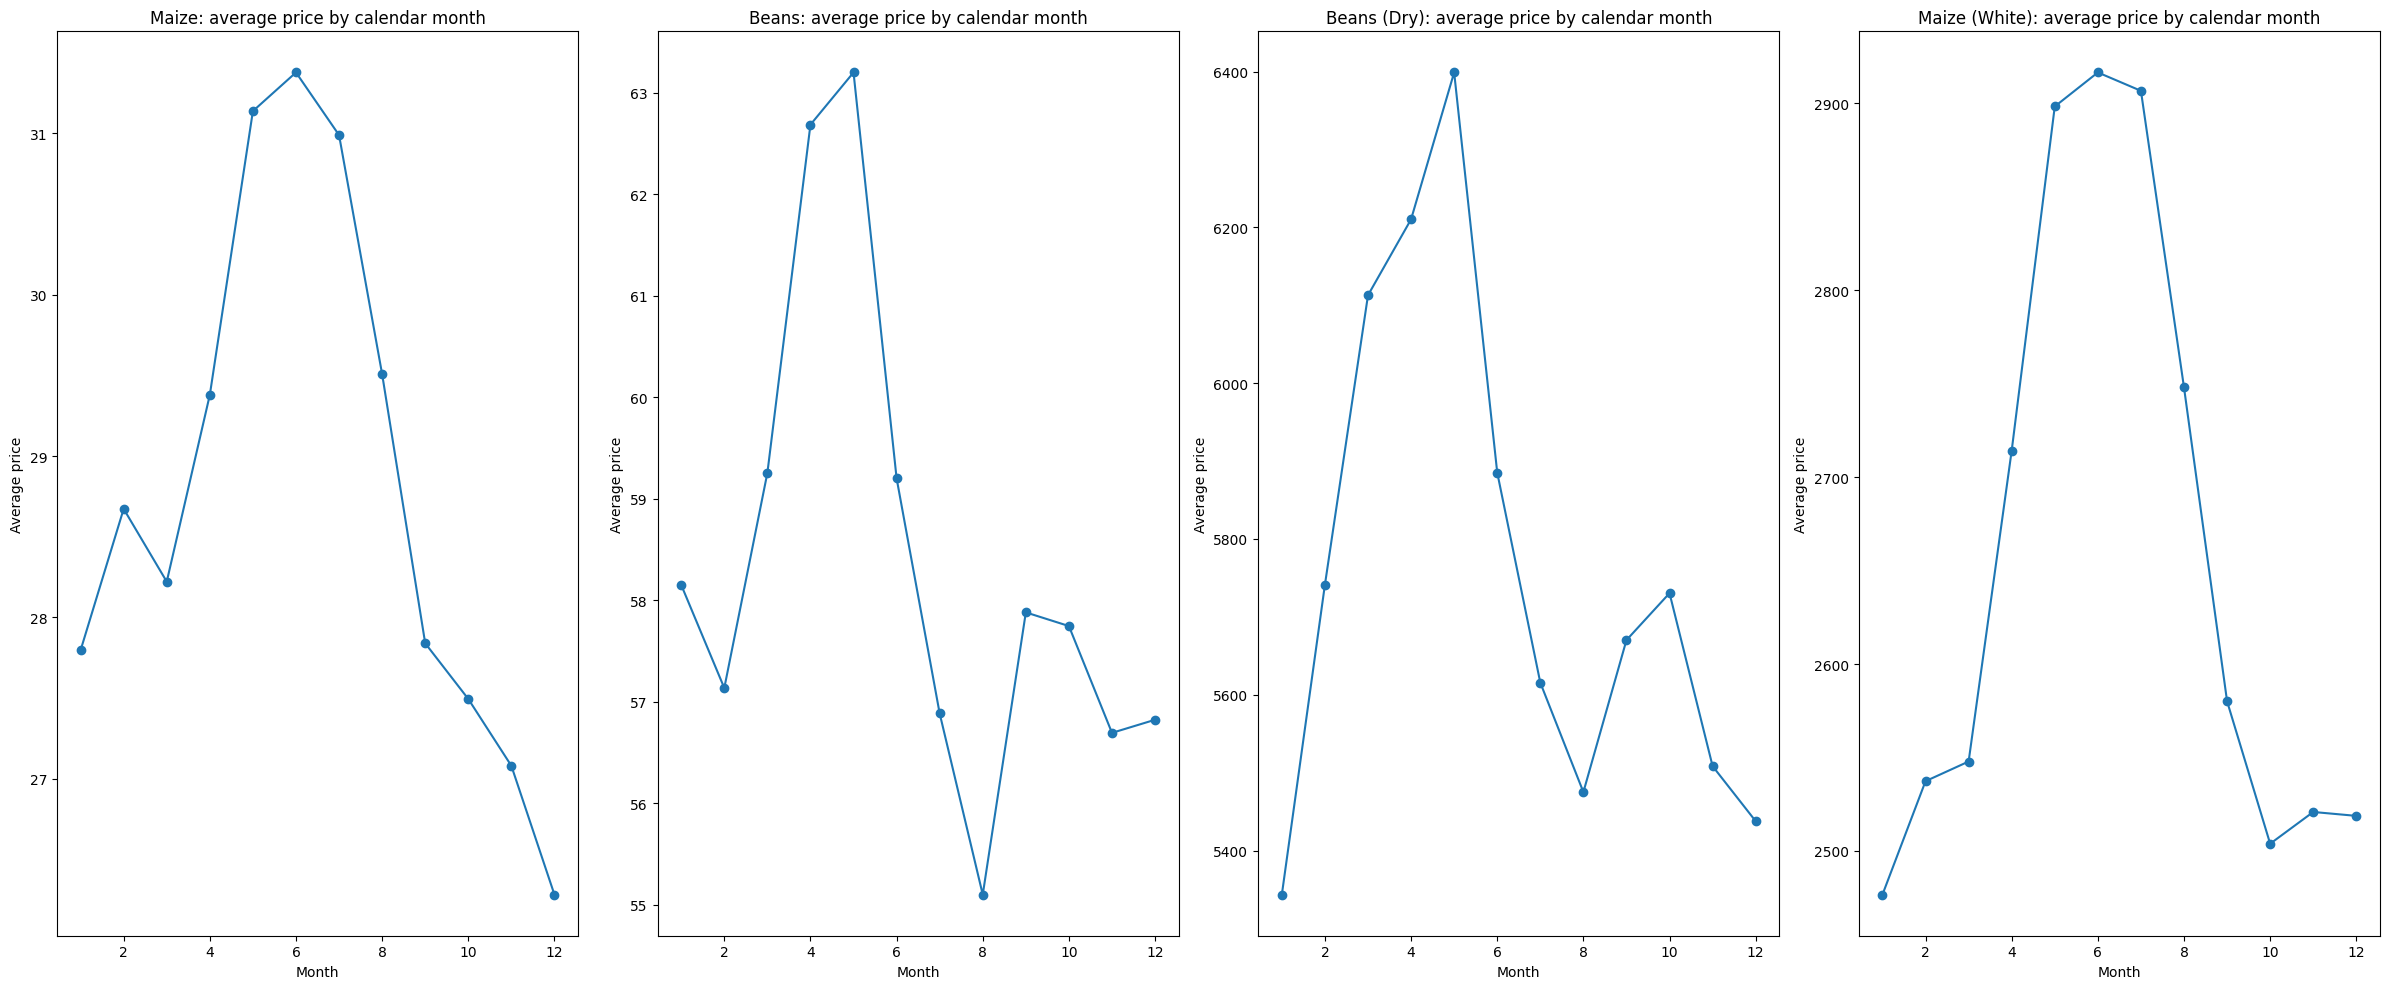

In [22]:
df['month'] = df['date'].dt.month

fig, axes = plt.subplots(1, len(FINAL_CROPS), figsize=(6 * len(FINAL_CROPS), 10), sharey=False)

for ax, crop in zip(axes, FINAL_CROPS):
    seasonal = df[df['commodity'] == crop].groupby('month')['price'].mean()
    ax.plot(seasonal.index, seasonal.values, marker='o')
    ax.set_title(f'{crop}: average price by calendar month')
    ax.set_xlabel('Month')
    ax.set_ylabel('Average price')

plt.tight_layout()
plt.show()

# 13. Volatility comparison across crops and markets

In [23]:
volatility = (
    df.groupby(['market', 'commodity'])['price']
    .agg(mean='mean', std='std')
    .assign(coefficient_of_variation=lambda x: x['std'] / x['mean'])
    .sort_values('coefficient_of_variation', ascending=False)
)
volatility

mean          std  coefficient_of_variation
market  commodity                                                        
Mombasa Maize            27.919323     9.634884                  0.345097
Kisumu  Maize (White)  2887.678354   969.453057                  0.335721
Mombasa Maize (White)  2497.040060   811.183674                  0.324858
Kisumu  Maize            30.471242     9.843357                  0.323038
Nairobi Maize (White)  2618.227824   806.845737                  0.308165
        Maize            29.242000     8.950687                  0.306090
Mombasa Beans            57.157762    16.612056                  0.290635
Nairobi Beans (Dry)    5585.531754  1519.046491                  0.271961
Kisumu  Beans (Dry)    6344.542000  1661.769938                  0.261921
Mombasa Beans (Dry)    5314.798144  1368.242687                  0.257440
Nakuru  Maize            27.664451     6.852671                  0.247707
Kisumu  Beans            63.748937    15.030506                  0.235777
Nakuru  Maize (White)  2562.272419   584.063780                  0.227948
Nairobi Beans            55.296319    12.129954                  0.219363
Nakuru  Beans (Dry)    6010.076613  1066.988872                  0.177533
        Beans            56.830465     8.378118                  0.147423

<Figure size 1000x600 with 0 Axes>

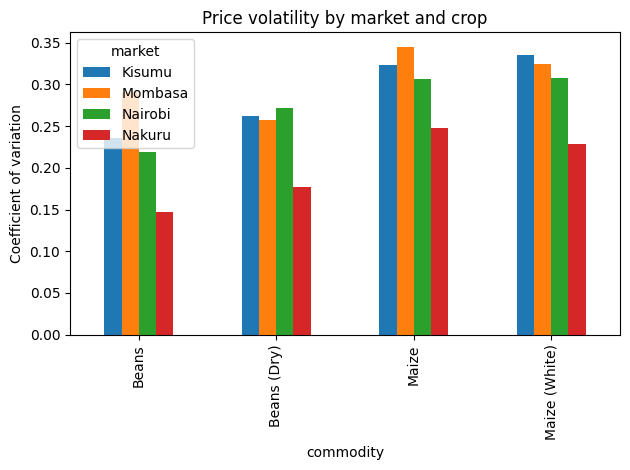

In [24]:
plt.figure(figsize=(10, 6))
volatility['coefficient_of_variation'].unstack(level=0).plot(kind='bar')
plt.ylabel('Coefficient of variation')
plt.title('Price volatility by market and crop')
plt.tight_layout()
plt.show()